In [ ]:
# Imports

import torch
import torch.nn as nn
import timm

from torchvision import transforms, datasets
from torch.utils.data import DataLoader

from tqdm import tqdm
import os

In [ ]:
# Device

device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


In [ ]:
data_path = "/content/drive/MyDrive/CIFAR100/CIFAR100/CIFAR100"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()

])


test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()

])

In [ ]:
train_dataset = datasets.CIFAR100(

    root=data_path,

    train=True,

    transform=train_transform,

    download=False

)



test_dataset = datasets.CIFAR100(

    root=data_path,

    train=False,

    transform=test_transform,

    download=False

)

In [ ]:
train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=2

)


test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2

)

In [ ]:
model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=100

)


model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

# **BASELINE** - **86.96%**

In [ ]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from tqdm import tqdm

def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device

):

    model.train()

    running_loss = 0


    for images,labels in tqdm(loader):


        images = images.to(device)

        labels = labels.to(device)


        optimizer.zero_grad()


        outputs = model(images)


        loss = criterion(

            outputs,

            labels

        )


        loss.backward()


        optimizer.step()


        running_loss += loss.item()


    return running_loss / len(loader)

In [ ]:
def evaluate(

    model,

    criterion,

    loader,

    device

):

    model.eval()

    total_loss = 0

    correct = 0

    total = 0


    with torch.no_grad():

        for images,labels in tqdm(loader):


            images = images.to(device)

            labels = labels.to(device)


            outputs = model(images)


            loss = criterion(

                outputs,

                labels

            )


            total_loss += loss.item()


            pred = torch.argmax(

                outputs,

                dim=1

            )


            correct += (

                pred == labels

            ).sum().item()


            total += labels.size(0)


    return (

        total_loss / len(loader),

        100 * correct / total

    )

In [ ]:
checkpoint_path = "/content/drive/MyDrive/vit_tiny_baseline_checkpoint.pth"

best_model_path = "/content/drive/MyDrive/vit_tiny_baseline_best.pth"

In [ ]:
epochs = 20

best_acc = 0


for epoch in range(epochs):


    train_loss = train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device

    )


    val_loss,val_acc = evaluate(

        model,

        criterion,

        test_loader,

        device

    )


    scheduler.step()


    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )


    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(

            model.state_dict(),

            best_model_path

        )

        print("Best model saved")


    torch.save(

        {

        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "best_acc":
            best_acc

        },

        checkpoint_path

    )

    print("Checkpoint saved")

100%|██████████| 157/157 [00:19<00:00,  7.97it/s]


----------------
Epoch 1/20
Train Loss: 1.5969
Val Loss: 0.7665
Val Accuracy: 77.27%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.83it/s]


----------------
Epoch 2/20
Train Loss: 0.7456
Val Loss: 0.6380
Val Accuracy: 80.52%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:18<00:00,  8.40it/s]


...

----------------
Epoch 18/20
Train Loss: 0.0310
Val Loss: 0.5132
Val Accuracy: 86.83%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:20<00:00,  7.72it/s]


----------------
Epoch 19/20
Train Loss: 0.0296
Val Loss: 0.5122
Val Accuracy: 86.83%
Checkpoint saved


100%|██████████| 157/157 [00:18<00:00,  8.57it/s]


----------------
Epoch 20/20
Train Loss: 0.0279
Val Loss: 0.5089
Val Accuracy: 86.96%
Best model saved
Checkpoint saved


# **MIXUP** - **86.02%**







In [ ]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=0.0,

    prob=1.0,

    switch_prob=0.0,

    num_classes=100

)


criterion = SoftTargetCrossEntropy()

In [ ]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation=None

):

    model.train()

    running_loss=0


    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        if augmentation:

            images,labels = augmentation(
                images,
                labels
            )



        optimizer.zero_grad()


        outputs=model(images)


        loss=criterion(
            outputs,
            labels
        )


        loss.backward()


        optimizer.step()


        running_loss += loss.item()



    return running_loss/len(loader)

In [ ]:
def evaluate(model,criterion,loader,device):

    model.eval()

    loss_total=0
    correct=0
    total=0


    with torch.no_grad():

        for images,labels in tqdm(loader):

            images=images.to(device)
            labels=labels.to(device)


            outputs=model(images)


            loss=criterion(
                outputs,
                labels
            )


            loss_total += loss.item()


            pred=torch.argmax(
                outputs,
                dim=1
            )


            correct += (
                pred==labels
            ).sum().item()


            total += labels.size(0)



    return (
        loss_total/len(loader),
        100*correct/total
    )

In [ ]:
checkpoint_path="/content/drive/MyDrive/vit_tiny_mixup_checkpoint.pth"

best_model_path="/content/drive/MyDrive/vit_tiny_mixup_best.pth"

In [ ]:
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/vit_tiny_mixup_best.pth",
        map_location=device
    )
)

model.eval()

loss,acc = evaluate(
    model,
    nn.CrossEntropyLoss(),
    test_loader,
    device
)

print("Accuracy:",acc)

100%|██████████| 157/157 [00:17<00:00,  8.96it/s]

Accuracy: 86.02


In [ ]:
checkpoint = torch.load(
    "/content/drive/MyDrive/vit_tiny_mixup_checkpoint.pth",
    map_location=device
)


print(
    "Last epoch:",
    checkpoint["epoch"]+1
)


print(
    "Best accuracy:",
    checkpoint["best_acc"]
)

Last epoch: 20
Best accuracy: 86.02


In [ ]:
test_loss, test_acc = evaluate(
    model,
    nn.CrossEntropyLoss(),
    test_loader,
    device
)

print("Test Accuracy:", test_acc)

100%|██████████| 157/157 [00:18<00:00,  8.48it/s]

Test Accuracy: 86.02


/*

100%|██████████| 782/782 [03:06<00:00,  4.19it/s]
100%|██████████| 157/157 [00:17<00:00,  9.18it/s]
----------------
Epoch 1/20
Train Loss: 3.2957511707340057
Val Accuracy: 72.69
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:13<00:00,  4.04it/s]
100%|██████████| 157/157 [00:17<00:00,  8.74it/s]
----------------
Epoch 2/20
Train Loss: 2.6382466152196042
Val Accuracy: 77.55
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:16<00:00,  3.97it/s]
100%|██████████| 157/157 [00:17<00:00,  8.83it/s]
----------------
Epoch 3/20
Train Loss: 2.5193463359647397
Val Accuracy: 80.47
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:16<00:00,  3.98it/s]
100%|██████████| 157/157 [00:18<00:00,  8.54it/s]
----------------
Epoch 4/20
Train Loss: 2.4929546453153995
Val Accuracy: 81.19
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:17<00:00,  3.96it/s]
100%|██████████| 157/157 [00:17<00:00,  8.82it/s]
----------------
Epoch 5/20
Train Loss: 2.3658252321850615
Val Accuracy: 82.22
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:18<00:00,  3.94it/s]
100%|██████████| 157/157 [00:17<00:00,  9.19it/s]
----------------
Epoch 6/20
Train Loss: 2.3461702691624535
Val Accuracy: 82.12
Checkpoint saved
100%|██████████| 782/782 [03:17<00:00,  3.96it/s]
100%|██████████| 157/157 [00:17<00:00,  9.19it/s]
----------------
Epoch 7/20
Train Loss: 2.3012379988684986
Val Accuracy: 82.85
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:19<00:00,  3.92it/s]
100%|██████████| 157/157 [00:17<00:00,  9.10it/s]
----------------
Epoch 8/20
Train Loss: 2.2899027122256093
Val Accuracy: 83.26
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:17<00:00,  3.95it/s]
100%|██████████| 157/157 [00:17<00:00,  9.01it/s]
----------------
Epoch 9/20
Train Loss: 2.202120601063799
Val Accuracy: 84.36
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:17<00:00,  3.96it/s]
100%|██████████| 157/157 [00:17<00:00,  9.10it/s]
----------------
Epoch 10/20
Train Loss: 2.1452643500874413
Val Accuracy: 84.65
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:16<00:00,  3.98it/s]
100%|██████████| 157/157 [00:17<00:00,  9.12it/s]
----------------
Epoch 11/20
Train Loss: 2.133792353712994
Val Accuracy: 84.56
Checkpoint saved
100%|██████████| 782/782 [03:15<00:00,  3.99it/s]
100%|██████████| 157/157 [00:17<00:00,  9.08it/s]
----------------
Epoch 12/20
Train Loss: 2.1033067002015957
Val Accuracy: 85.42
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:15<00:00,  3.99it/s]
100%|██████████| 157/157 [00:19<00:00,  7.94it/s]
----------------
Epoch 13/20
Train Loss: 2.0569169525905036
Val Accuracy: 85.22
Checkpoint saved
100%|██████████| 782/782 [03:15<00:00,  3.99it/s]
100%|██████████| 157/157 [00:18<00:00,  8.52it/s]
----------------
Epoch 14/20
Train Loss: 2.1171787712732546
Val Accuracy: 85.31
Checkpoint saved
100%|██████████| 782/782 [03:17<00:00,  3.97it/s]
100%|██████████| 157/157 [00:17<00:00,  8.84it/s]
----------------
Epoch 15/20
Train Loss: 2.0311712572336806
Val Accuracy: 85.95
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:16<00:00,  3.98it/s]
100%|██████████| 157/157 [00:20<00:00,  7.60it/s]
----------------
Epoch 16/20
Train Loss: 2.0318116478602906
Val Accuracy: 85.83
Checkpoint saved
100%|██████████| 782/782 [03:14<00:00,  4.01it/s]
100%|██████████| 157/157 [00:17<00:00,  8.82it/s]
----------------
Epoch 17/20
Train Loss: 2.0054315687597866
Val Accuracy: 85.96
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:16<00:00,  3.99it/s]
100%|██████████| 157/157 [00:18<00:00,  8.64it/s]
----------------
Epoch 18/20
Train Loss: 2.0261638941209945
Val Accuracy: 85.87
Checkpoint saved
100%|██████████| 782/782 [03:15<00:00,  3.99it/s]
100%|██████████| 157/157 [00:18<00:00,  8.68it/s]
----------------
Epoch 19/20
Train Loss: 2.017410188684683
Val Accuracy: 86.01
Best model saved
Checkpoint saved
100%|██████████| 782/782 [03:15<00:00,  3.99it/s]
100%|██████████| 157/157 [00:17<00:00,  8.98it/s]
----------------
Epoch 20/20
Train Loss: 2.0124595371048772
Val Accuracy: 86.02
Best model saved
### **Checkpoint saved**

# **CUTMIX** - **86.91 %**

In [ ]:
model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=True,
    num_classes=100
)

model=model.to(device)

In [ ]:
# CUTMIX

from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


augmentation = Mixup(

    mixup_alpha=0.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=1.0,

    num_classes=100

)


criterion = SoftTargetCrossEntropy()

In [ ]:
model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=True,
    num_classes=100
)

model = model.to(device)

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05
)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

In [ ]:
images,labels = next(iter(train_loader))

images = images.to(device)

out = model(images)

print(out.shape)

torch.Size([64, 100])


In [ ]:
checkpoint_path="/content/drive/MyDrive/vit_tiny_cutmix_checkpoint.pth"

best_model_path="/content/drive/MyDrive/vit_tiny_cutmix_best.pth"

In [ ]:
epochs=20

best_acc=0


for epoch in range(20):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )


    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc = val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "best_acc":
            best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:17<00:00,  8.72it/s]


----------------
Epoch 1/20
Train Loss: 3.2828
Val Loss: 1.1058
Val Accuracy: 72.77%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.88it/s]


----------------
Epoch 2/20
Train Loss: 2.6087
Val Loss: 0.8895
Val Accuracy: 78.31%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.85it/s]


...

----------------
Epoch 18/20
Train Loss: 1.7454
Val Loss: 0.5932
Val Accuracy: 86.67%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.94it/s]


----------------
Epoch 19/20
Train Loss: 1.7359
Val Loss: 0.5882
Val Accuracy: 86.91%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.80it/s]


----------------
Epoch 20/20
Train Loss: 1.7483
Val Loss: 0.5887
Val Accuracy: 86.86%
Checkpoint saved


# **RANDAUGMENT** - **86.78%**

In [ ]:
import timm
import torch
import torch.nn as nn


model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=True,
    num_classes=100
)

model = model.to(device)

In [ ]:
from torchvision import transforms


train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor()

])


test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()

])

In [ ]:
train_dataset = datasets.CIFAR100(

    root=data_path,

    train=True,

    transform=train_transform,

    download=False

)


test_dataset = datasets.CIFAR100(

    root=data_path,

    train=False,

    transform=test_transform,

    download=False

)

In [ ]:
train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=2

)


test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2

)

In [ ]:
criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from tqdm import tqdm


def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device

):

    model.train()

    running_loss = 0


    for images,labels in tqdm(loader):

        images = images.to(device)

        labels = labels.to(device)


        optimizer.zero_grad()


        outputs = model(images)


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()


        optimizer.step()


        running_loss += loss.item()


    return running_loss/len(loader)

In [ ]:
def evaluate(

    model,

    criterion,

    loader,

    device

):

    model.eval()

    loss_total = 0

    correct = 0

    total = 0


    with torch.no_grad():

        for images,labels in tqdm(loader):

            images = images.to(device)

            labels = labels.to(device)


            outputs = model(images)


            loss = criterion(
                outputs,
                labels
            )


            loss_total += loss.item()


            pred = torch.argmax(
                outputs,
                dim=1
            )


            correct += (
                pred == labels
            ).sum().item()


            total += labels.size(0)


    return (

        loss_total/len(loader),

        100*correct/total

    )

In [ ]:
checkpoint_path = "/content/drive/MyDrive/vit_tiny_randaugment_checkpoint.pth"


best_model_path = "/content/drive/MyDrive/vit_tiny_randaugment_best.pth"

In [ ]:
epochs = 20

best_acc = 0


for epoch in range(epochs):


    train_loss = train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device

    )


    val_loss,val_acc = evaluate(

        model,

        criterion,

        test_loader,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc = val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "best_acc":
            best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:17<00:00,  8.74it/s]


----------------
Epoch 1/20
Train Loss: 1.7394
Val Loss: 0.8199
Val Accuracy: 75.91%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:18<00:00,  8.64it/s]


----------------
Epoch 2/20
Train Loss: 0.7623
Val Loss: 0.6323
Val Accuracy: 80.61%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:20<00:00,  7.59it/s]


...

----------------
Epoch 18/20
Train Loss: 0.0305
Val Loss: 0.5179
Val Accuracy: 86.73%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.06it/s]


----------------
Epoch 19/20
Train Loss: 0.0283
Val Loss: 0.5143
Val Accuracy: 86.78%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:20<00:00,  7.68it/s]


----------------
Epoch 20/20
Train Loss: 0.0293
Val Loss: 0.5142
Val Accuracy: 86.69%
Checkpoint saved


## **MIXUP+CUTMIX** - **87.0 %**

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()

])


test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()

])

In [ ]:
train_dataset = datasets.CIFAR100(

    root=data_path,

    train=True,

    transform=train_transform,

    download=False

)


test_dataset = datasets.CIFAR100(

    root=data_path,

    train=False,

    transform=test_transform,

    download=False

)

In [ ]:
train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=2

)


test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2

)

In [ ]:
model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=100

)


model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [ ]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=0.5,

    mode="batch",

    num_classes=100

)


criterion = SoftTargetCrossEntropy()

In [ ]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):

    model.train()

    running_loss=0


    for images,labels in tqdm(loader):


        images = images.to(device)

        labels = labels.to(device)



        images,labels = augmentation(

            images,

            labels

        )



        optimizer.zero_grad()


        outputs = model(images)


        loss = criterion(

            outputs,

            labels

        )


        loss.backward()


        optimizer.step()


        running_loss += loss.item()



    return running_loss/len(loader)

In [ ]:
def evaluate(

    model,

    criterion,

    loader,

    device

):

    model.eval()

    total_loss=0

    correct=0

    total=0


    with torch.no_grad():

        for images,labels in tqdm(loader):


            images=images.to(device)

            labels=labels.to(device)



            outputs=model(images)


            loss=criterion(

                outputs,

                labels

            )


            total_loss += loss.item()


            pred=torch.argmax(

                outputs,

                dim=1

            )


            correct += (

                pred==labels

            ).sum().item()


            total += labels.size(0)



    return (

        total_loss/len(loader),

        100*correct/total

    )

In [ ]:
checkpoint_path = "/content/drive/MyDrive/vit_tiny_mixup_cutmix_checkpoint.pth"


best_model_path = "/content/drive/MyDrive/vit_tiny_mixup_cutmix_best.pth"

In [ ]:
epochs=20

best_acc=0


for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )


    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "best_acc":
            best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:17<00:00,  9.19it/s]


----------------
Epoch 1/20
Train Loss: 2.7005
Val Loss: 0.9469
Val Accuracy: 78.80%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.19it/s]


----------------
Epoch 2/20
Train Loss: 2.5454
Val Loss: 0.8846
Val Accuracy: 80.76%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.19it/s]


...

----------------
Epoch 18/20
Train Loss: 1.9518
Val Loss: 0.6550
Val Accuracy: 87.03%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.76it/s]


----------------
Epoch 19/20
Train Loss: 1.9341
Val Loss: 0.6521
Val Accuracy: 87.00%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.13it/s]


----------------
Epoch 20/20
Train Loss: 1.9853
Val Loss: 0.6521
Val Accuracy: 87.00%
Checkpoint saved


# **MIXUP + RANDAUGMENT** **- 86.20%**

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor()

])


test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()

])

In [ ]:
train_dataset = datasets.CIFAR100(

    root=data_path,

    train=True,

    transform=train_transform,

    download=False

)


test_dataset = datasets.CIFAR100(

    root=data_path,

    train=False,

    transform=test_transform,

    download=False

)

In [ ]:
model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=100

)


model=model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [ ]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


mixup_fn = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=0.0,

    prob=1.0,

    switch_prob=0.0,

    num_classes=100

)


criterion = SoftTargetCrossEntropy()

In [ ]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    mixup_fn

):

    model.train()

    running_loss=0


    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels = mixup_fn(

            images,

            labels

        )



        optimizer.zero_grad()


        outputs=model(images)


        loss=criterion(

            outputs,

            labels

        )


        loss.backward()


        optimizer.step()


        running_loss += loss.item()



    return running_loss/len(loader)

In [ ]:
def evaluate(

    model,

    criterion,

    loader,

    device

):

    model.eval()


    loss_total=0

    correct=0

    total=0


    with torch.no_grad():


        for images,labels in tqdm(loader):


            images=images.to(device)

            labels=labels.to(device)



            outputs=model(images)


            loss=criterion(

                outputs,

                labels

            )


            loss_total += loss.item()


            pred=torch.argmax(

                outputs,

                dim=1

            )


            correct += (

                pred==labels

            ).sum().item()


            total += labels.size(0)



    return (

        loss_total/len(loader),

        100*correct/total

    )

In [ ]:
checkpoint_path="/content/drive/MyDrive/vit_tiny_mixup_randaugment_checkpoint.pth"


best_model_path="/content/drive/MyDrive/vit_tiny_mixup_randaugment_best.pth"

In [ ]:
epochs=20

best_acc=0


for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        mixup_fn

    )


    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "best_acc":
            best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:17<00:00,  8.84it/s]


----------------
Epoch 1/20
Train Loss: 3.2928
Val Loss: 1.2276
Val Accuracy: 71.82%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.21it/s]


----------------
Epoch 2/20
Train Loss: 2.7167
Val Loss: 0.9729
Val Accuracy: 78.42%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.18it/s]


...

100%|██████████| 157/157 [00:17<00:00,  9.17it/s]


----------------
Epoch 11/20
Train Loss: 2.1255
Val Loss: 0.7266
Val Accuracy: 84.88%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.09it/s]


----------------
Epoch 12/20
Train Loss: 2.1216
Val Loss: 0.7232
Val Accuracy: 84.44%
Checkpoint saved


 14%|█▍        | 112/782 [00:29<02:55,  3.81it/s]

In [ ]:
epochs = 20

for epoch in range(start_epoch, epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        mixup_fn
    )


    val_loss, val_acc = evaluate(
        model,
        nn.CrossEntropyLoss(),
        test_loader,
        device
    )


    scheduler.step()


    print("----------------")
    print(f"Epoch {epoch+1}/20")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.2f}%")


    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/vit_tiny_mixup_randaugment_best.pth"
        )

        print("Best model saved")


    torch.save(
        {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_acc": best_acc
        },
        checkpoint_path
    )

    print("Checkpoint saved")

100%|██████████| 157/157 [00:17<00:00,  8.94it/s]


----------------
Epoch 13/20
Train Loss: 2.3044
Val Loss: 0.6885
Val Accuracy: 85.59%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.14it/s]


----------------
Epoch 14/20
Train Loss: 2.2830
Val Loss: 0.6843
Val Accuracy: 85.55%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.09it/s]


...

----------------
Epoch 18/20
Train Loss: 2.2548
Val Loss: 0.6564
Val Accuracy: 86.09%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:18<00:00,  8.66it/s]


----------------
Epoch 19/20
Train Loss: 2.2300
Val Loss: 0.6566
Val Accuracy: 86.20%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.13it/s]


----------------
Epoch 20/20
Train Loss: 2.2555
Val Loss: 0.6566
Val Accuracy: 86.20%
Checkpoint saved


In [ ]:
import os

print(os.path.exists(
"/content/drive/MyDrive/vit_tiny_mixup_randaugment_checkpoint.pth"
))

True


In [ ]:
checkpoint_path = "/content/drive/MyDrive/vit_tiny_mixup_randaugment_checkpoint.pth"


checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)


model.load_state_dict(
    checkpoint["model_state_dict"]
)


optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)


scheduler.load_state_dict(
    checkpoint["scheduler_state_dict"]
)


start_epoch = checkpoint["epoch"] + 1


best_acc = checkpoint["best_acc"]


print("Resume from epoch:", start_epoch)
print("Previous best accuracy:", best_acc)

Resume from epoch: 12
Previous best accuracy: 84.88


# **CUTMIX+RANDAUGMENT** - **87.41%**

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor()

])


test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()

])

In [ ]:
train_dataset = datasets.CIFAR100(

    root=data_path,

    train=True,

    transform=train_transform,

    download=False

)


test_dataset = datasets.CIFAR100(

    root=data_path,

    train=False,

    transform=test_transform,

    download=False

)

In [ ]:
train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=2

)


test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2

)

In [ ]:
model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=100

)


model=model.to(device)

In [ ]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


cutmix_fn = Mixup(

    mixup_alpha=0.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=0.0,

    num_classes=100

)


criterion = SoftTargetCrossEntropy()

In [ ]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    cutmix_fn

):

    model.train()

    running_loss=0


    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels = cutmix_fn(

            images,

            labels

        )


        optimizer.zero_grad()


        outputs=model(images)


        loss=criterion(

            outputs,

            labels

        )


        loss.backward()


        optimizer.step()


        running_loss += loss.item()



    return running_loss/len(loader)

In [ ]:
def evaluate(

    model,

    criterion,

    loader,

    device

):

    model.eval()


    total_loss=0

    correct=0

    total=0


    with torch.no_grad():


        for images,labels in tqdm(loader):


            images=images.to(device)

            labels=labels.to(device)



            outputs=model(images)


            loss=criterion(

                outputs,

                labels

            )


            total_loss += loss.item()


            pred=torch.argmax(

                outputs,

                dim=1

            )


            correct += (

                pred==labels

            ).sum().item()


            total += labels.size(0)



    return (

        total_loss/len(loader),

        100*correct/total

    )

In [ ]:
checkpoint_path="/content/drive/MyDrive/vit_tiny_cutmix_randaugment_checkpoint.pth"


best_model_path="/content/drive/MyDrive/vit_tiny_cutmix_randaugment_best.pth"

In [ ]:
epochs=20

best_acc=0


for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        cutmix_fn

    )


    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "best_acc":
            best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:17<00:00,  9.01it/s]


----------------
Epoch 1/20
Train Loss: 3.4737
Val Loss: 1.2070
Val Accuracy: 70.70%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.17it/s]


----------------
Epoch 2/20
Train Loss: 2.7872
Val Loss: 0.9224
Val Accuracy: 76.98%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.08it/s]


...

----------------
Epoch 18/20
Train Loss: 1.9959
Val Loss: 0.5515
Val Accuracy: 87.35%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.19it/s]


----------------
Epoch 19/20
Train Loss: 1.9811
Val Loss: 0.5477
Val Accuracy: 87.36%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.79it/s]


----------------
Epoch 20/20
Train Loss: 1.9607
Val Loss: 0.5474
Val Accuracy: 87.41%
Best model saved
Checkpoint saved


# **CUTMIX+MIXUP+RANDAUGMENT** - **87.16%**

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor()

])


test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()

])

In [ ]:
train_dataset = datasets.CIFAR100(

    root=data_path,

    train=True,

    transform=train_transform,

    download=False

)


test_dataset = datasets.CIFAR100(

    root=data_path,

    train=False,

    transform=test_transform,

    download=False

)

In [ ]:
train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=2

)


test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2

)

In [ ]:
model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=100

)


model=model.to(device)

In [ ]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=0.5,

    num_classes=100

)


criterion = SoftTargetCrossEntropy()

In [ ]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):

    model.train()

    running_loss=0


    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels = augmentation(

            images,

            labels

        )



        optimizer.zero_grad()


        outputs=model(images)


        loss=criterion(

            outputs,

            labels

        )


        loss.backward()


        optimizer.step()


        running_loss += loss.item()



    return running_loss/len(loader)

In [ ]:
def evaluate(

    model,

    criterion,

    loader,

    device

):

    model.eval()


    total_loss=0

    correct=0

    total=0



    with torch.no_grad():


        for images,labels in tqdm(loader):


            images=images.to(device)

            labels=labels.to(device)



            outputs=model(images)



            loss=criterion(

                outputs,

                labels

            )


            total_loss += loss.item()



            pred=torch.argmax(

                outputs,

                dim=1

            )


            correct += (

                pred==labels

            ).sum().item()


            total += labels.size(0)



    return (

        total_loss/len(loader),

        100*correct/total

    )

In [ ]:
checkpoint_path="/content/drive/MyDrive/vit_tiny_mixup_cutmix_randaugment_checkpoint.pth"


best_model_path="/content/drive/MyDrive/vit_tiny_mixup_cutmix_randaugment_best.pth"

In [ ]:
checkpoint = torch.load(

    "/content/drive/MyDrive/vit_tiny_mixup_cutmix_randaugment_checkpoint.pth",

    map_location=device

)


model.load_state_dict(

    checkpoint["model_state_dict"]

)


optimizer.load_state_dict(

    checkpoint["optimizer_state_dict"]

)


scheduler.load_state_dict(

    checkpoint["scheduler_state_dict"]

)


start_epoch = checkpoint["epoch"] + 1


best_acc = checkpoint["best_acc"]


print("Resume from epoch:", start_epoch)

print("Best accuracy:", best_acc)

Resume from epoch: 19
Best accuracy: 87.08


In [ ]:
epochs=20

best_acc=0


for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "best_acc":
            best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:18<00:00,  8.64it/s]


----------------
Epoch 1/20
Train Loss: 3.4893
Val Loss: 1.2622
Val Accuracy: 70.42%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:18<00:00,  8.34it/s]


----------------
Epoch 2/20
Train Loss: 2.8967
Val Loss: 1.0658
Val Accuracy: 75.91%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:18<00:00,  8.27it/s]


...

100%|██████████| 157/157 [00:17<00:00,  9.17it/s]


----------------
Epoch 18/20
Train Loss: 2.1749
Val Loss: 0.6393
Val Accuracy: 87.07%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.01it/s]


----------------
Epoch 19/20
Train Loss: 2.1735
Val Loss: 0.6272
Val Accuracy: 87.08%
Best model saved
Checkpoint saved


 70%|██████▉   | 545/782 [02:21<01:10,  3.36it/s]

In [ ]:
# ==============================
# RESUME ViT-TINY MIXUP+CUTMIX+RANDAUGMENT TRAINING
# ==============================

import torch
import torch.nn as nn
import timm

from tqdm import tqdm


# Device

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)



# -------------------------------
# Recreate Model
# -------------------------------

model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=100

)


model = model.to(device)



# -------------------------------
# Recreate Augmentation
# -------------------------------

from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=0.5,

    num_classes=100

)


criterion = SoftTargetCrossEntropy()



# -------------------------------
# Optimizer
# -------------------------------

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)



# -------------------------------
# Scheduler
# -------------------------------

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)



# -------------------------------
# Paths
# -------------------------------

checkpoint_path="/content/drive/MyDrive/vit_tiny_mixup_cutmix_randaugment_checkpoint.pth"


best_model_path="/content/drive/MyDrive/vit_tiny_mixup_cutmix_randaugment_best.pth"



# -------------------------------
# LOAD CHECKPOINT
# -------------------------------

checkpoint = torch.load(

    checkpoint_path,

    map_location=device

)


model.load_state_dict(

    checkpoint["model_state_dict"]

)


optimizer.load_state_dict(

    checkpoint["optimizer_state_dict"]

)


scheduler.load_state_dict(

    checkpoint["scheduler_state_dict"]

)


start_epoch = checkpoint["epoch"] + 1


best_acc = checkpoint["best_acc"]


print("----------------")

print("Resuming from epoch:", start_epoch)

print("Best accuracy:", best_acc)

print("----------------")



# -------------------------------
# Evaluation Function
# -------------------------------

def evaluate(

    model,

    criterion,

    loader,

    device

):

    model.eval()


    total_loss = 0

    correct = 0

    total = 0


    with torch.no_grad():


        for images,labels in tqdm(loader):


            images = images.to(device)

            labels = labels.to(device)



            outputs = model(images)



            loss = criterion(

                outputs,

                labels

            )


            total_loss += loss.item()



            pred = torch.argmax(

                outputs,

                dim=1

            )


            correct += (

                pred == labels

            ).sum().item()



            total += labels.size(0)



    return (

        total_loss / len(loader),

        100 * correct / total

    )



# -------------------------------
# Training Function
# -------------------------------

def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):

    model.train()


    running_loss = 0



    for images,labels in tqdm(loader):


        images = images.to(device)

        labels = labels.to(device)



        images,labels = augmentation(

            images,

            labels

        )


        optimizer.zero_grad()



        outputs = model(images)



        loss = criterion(

            outputs,

            labels

        )


        loss.backward()


        optimizer.step()



        running_loss += loss.item()



    return running_loss / len(loader)




# -------------------------------
# Continue Remaining Epochs
# -------------------------------

epochs = 20



for epoch in range(start_epoch, epochs):


    train_loss = train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc = evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )



    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    # Save best model

    if val_acc > best_acc:


        best_acc = val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    # Save checkpoint

    torch.save(

        {

        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "best_acc":
            best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

Device: cuda
----------------
Resuming from epoch: 19
Best accuracy: 87.08
----------------


100%|██████████| 157/157 [00:17<00:00,  9.00it/s]


----------------
Epoch 20/20
Train Loss: 2.1697
Val Loss: 0.6294
Val Accuracy: 87.16%
Best model saved
Checkpoint saved


# **TEST ACCURACIES**

In [ ]:
model_path = "/content/drive/MyDrive/vit_tiny_mixup_cutmix_randaugment_best.pth"


model.load_state_dict(

    torch.load(

        model_path,

        map_location=device

    )

)


model = model.to(device)

model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
correct = 0
total = 0


with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        predictions = torch.argmax(

            outputs,

            dim=1

        )


        correct += (

            predictions == labels

        ).sum().item()


        total += labels.size(0)



accuracy = 100 * correct / total


print("------------------")

print(f"Test Accuracy: {accuracy:.2f}%")

print("------------------")

100%|██████████| 157/157 [00:18<00:00,  8.41it/s]

------------------
Test Accuracy: 87.16%
------------------


In [ ]:
model_path = "/content/drive/MyDrive/vit_tiny_cutmix_best.pth"


model.load_state_dict(

    torch.load(

        model_path,

        map_location=device

    )

)


model = model.to(device)

model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
correct = 0
total = 0


with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        predictions = torch.argmax(

            outputs,

            dim=1

        )


        correct += (

            predictions == labels

        ).sum().item()


        total += labels.size(0)



accuracy = 100 * correct / total


print("------------------")

print(f"Test Accuracy: {accuracy:.2f}%")

print("------------------")

100%|██████████| 157/157 [00:17<00:00,  8.94it/s]

------------------
Test Accuracy: 86.91%
------------------


In [ ]:
model_path = "/content/drive/MyDrive/vit_tiny_mixup_best.pth"


model.load_state_dict(

    torch.load(

        model_path,

        map_location=device

    )

)


model = model.to(device)

model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
correct = 0
total = 0


with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        predictions = torch.argmax(

            outputs,

            dim=1

        )


        correct += (

            predictions == labels

        ).sum().item()


        total += labels.size(0)



accuracy = 100 * correct / total


print("------------------")

print(f"Test Accuracy: {accuracy:.2f}%")

print("------------------")

100%|██████████| 157/157 [00:17<00:00,  9.04it/s]

------------------
Test Accuracy: 86.02%
------------------


In [ ]:
model_path = "/content/drive/MyDrive/vit_tiny_mixup_cutmix_best.pth"


model.load_state_dict(

    torch.load(

        model_path,

        map_location=device

    )

)


model = model.to(device)

model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
correct = 0
total = 0


with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        predictions = torch.argmax(

            outputs,

            dim=1

        )


        correct += (

            predictions == labels

        ).sum().item()


        total += labels.size(0)



accuracy = 100 * correct / total


print("------------------")

print(f"Test Accuracy: {accuracy:.2f}%")

print("------------------")

100%|██████████| 157/157 [00:17<00:00,  9.10it/s]

------------------
Test Accuracy: 87.07%
------------------


In [ ]:
model_path = "/content/drive/MyDrive/vit_tiny_baseline_best.pth"


model.load_state_dict(

    torch.load(

        model_path,

        map_location=device

    )

)


model = model.to(device)

model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
correct = 0
total = 0


with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        predictions = torch.argmax(

            outputs,

            dim=1

        )


        correct += (

            predictions == labels

        ).sum().item()


        total += labels.size(0)



accuracy = 100 * correct / total


print("------------------")

print(f"Test Accuracy: {accuracy:.2f}%")

print("------------------")

100%|██████████| 157/157 [11:48<00:00,  4.52s/it]

------------------
Test Accuracy: 86.96%
------------------


In [ ]:
model_path = "/content/drive/MyDrive/vit_tiny_randaugment_best (1).pth"


model.load_state_dict(

    torch.load(

        model_path,

        map_location=device

    )

)


model = model.to(device)

model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
correct = 0
total = 0


with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        predictions = torch.argmax(

            outputs,

            dim=1

        )


        correct += (

            predictions == labels

        ).sum().item()


        total += labels.size(0)



accuracy = 100 * correct / total


print("------------------")

print(f"Test Accuracy: {accuracy:.2f}%")

print("------------------")

100%|██████████| 157/157 [10:43<00:00,  4.10s/it]

------------------
Test Accuracy: 86.78%
------------------


In [ ]:
model_path = "/content/drive/MyDrive/vit_tiny_cutmix_randaugment_best.pth"


model.load_state_dict(

    torch.load(

        model_path,

        map_location=device

    )

)


model = model.to(device)

model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
correct = 0
total = 0


with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        predictions = torch.argmax(

            outputs,

            dim=1

        )


        correct += (

            predictions == labels

        ).sum().item()


        total += labels.size(0)



accuracy = 100 * correct / total


print("------------------")

print(f"Test Accuracy: {accuracy:.2f}%")

print("------------------")

100%|██████████| 157/157 [11:24<00:00,  4.36s/it]

------------------
Test Accuracy: 87.41%
------------------


In [ ]:
model_path = "/content/drive/MyDrive/vit_tiny_mixup_randaugment_best (3).pth"


model.load_state_dict(

    torch.load(

        model_path,

        map_location=device

    )

)


model = model.to(device)

model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
correct = 0
total = 0


with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        predictions = torch.argmax(

            outputs,

            dim=1

        )


        correct += (

            predictions == labels

        ).sum().item()


        total += labels.size(0)



accuracy = 100 * correct / total


print("------------------")

print(f"Test Accuracy: {accuracy:.2f}%")

print("------------------")

100%|██████████| 157/157 [11:11<00:00,  4.28s/it]

------------------
Test Accuracy: 86.20%
------------------


In [ ]:
model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=100
)


best_model_path = "/content/drive/MyDrive/vit_tiny_cutmix_randaugment_best.pth"


checkpoint = torch.load(
    best_model_path,
    map_location=device
)


model.load_state_dict(checkpoint)


model = model.to(device)


model.eval()


print("Best model loaded successfully")

Best model loaded successfully


In [ ]:
import numpy as np


def get_predictions(model, loader, device):

    model.eval()

    all_preds = []
    all_labels = []


    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)


            outputs = model(images)


            preds = torch.argmax(
                outputs,
                dim=1
            )


            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )


    return np.array(all_labels), np.array(all_preds)

In [ ]:
y_true, y_pred = get_predictions(

    model,

    test_loader,

    device

)

100%|██████████| 157/157 [11:58<00:00,  4.58s/it]


In [ ]:
# Classification Report

from sklearn.metrics import classification_report


report = classification_report(

    y_true,

    y_pred,

    target_names=test_dataset.classes

)


print(report)

               precision    recall  f1-score   support

        apple       0.91      0.96      0.94       100
aquarium_fish       0.95      0.94      0.94       100
         baby       0.73      0.79      0.76       100
         bear       0.84      0.81      0.83       100
       beaver       0.81      0.83      0.82       100
          bed       0.90      0.88      0.89       100
          bee       0.95      0.94      0.94       100
       beetle       0.91      0.89      0.90       100
      bicycle       0.97      0.93      0.95       100
       bottle       0.97      0.94      0.95       100
         bowl       0.82      0.74      0.78       100
          boy       0.64      0.70      0.67       100
       bridge       0.93      0.90      0.91       100
          bus       0.90      0.85      0.88       100
    butterfly       0.97      0.91      0.94       100
        camel       0.92      0.93      0.93       100
          can       0.93      0.89      0.91       100
       ca

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score


precision = precision_score(

    y_true,

    y_pred,

    average="macro"

)


recall = recall_score(

    y_true,

    y_pred,

    average="macro"

)


f1 = f1_score(

    y_true,

    y_pred,

    average="macro"

)


print("Precision:",precision)
print("Recall:",recall)
print("F1:",f1)

Precision: 0.8750184744088004
Recall: 0.8741
F1: 0.8741411147175381


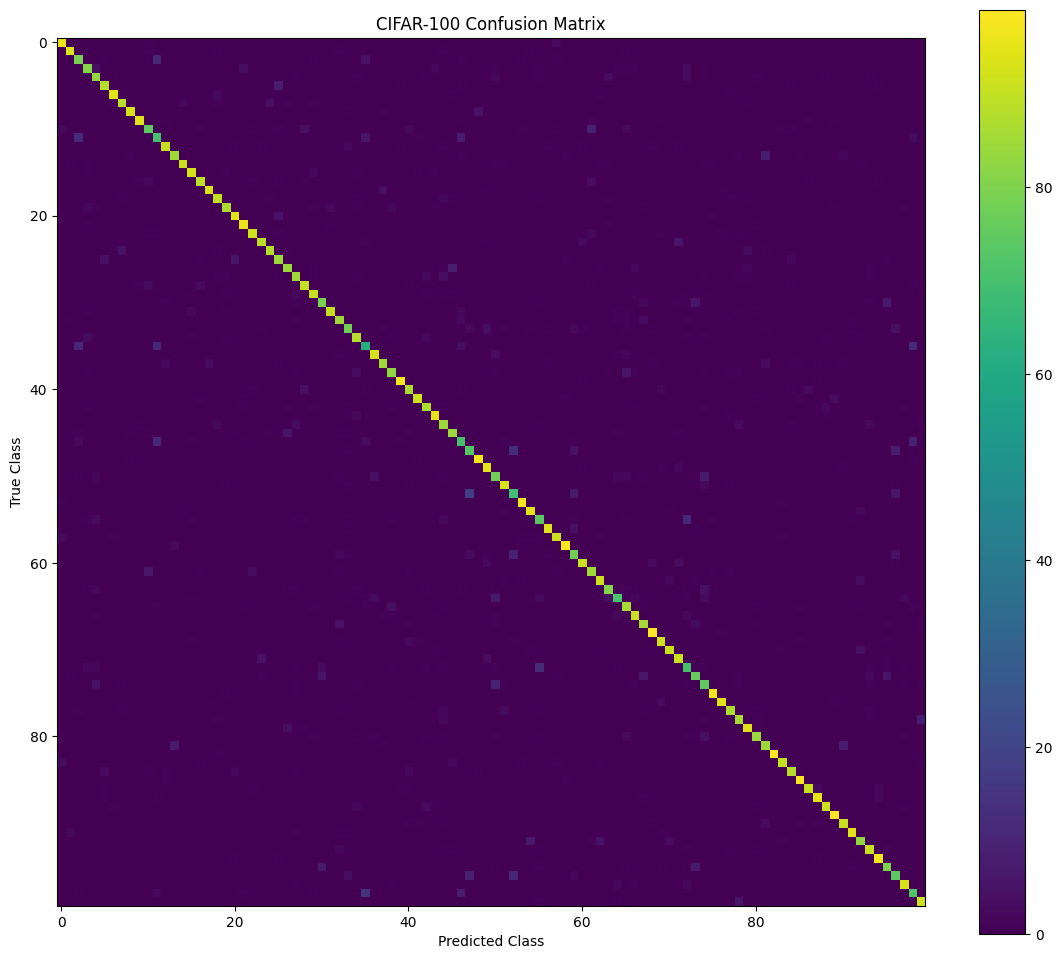

In [ ]:
# CM

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


cm = confusion_matrix(

    y_true,

    y_pred

)


plt.figure(figsize=(14,12))


plt.imshow(cm)


plt.colorbar()


plt.xlabel("Predicted Class")

plt.ylabel("True Class")


plt.title(
    "CIFAR-100 Confusion Matrix"
)


plt.show()

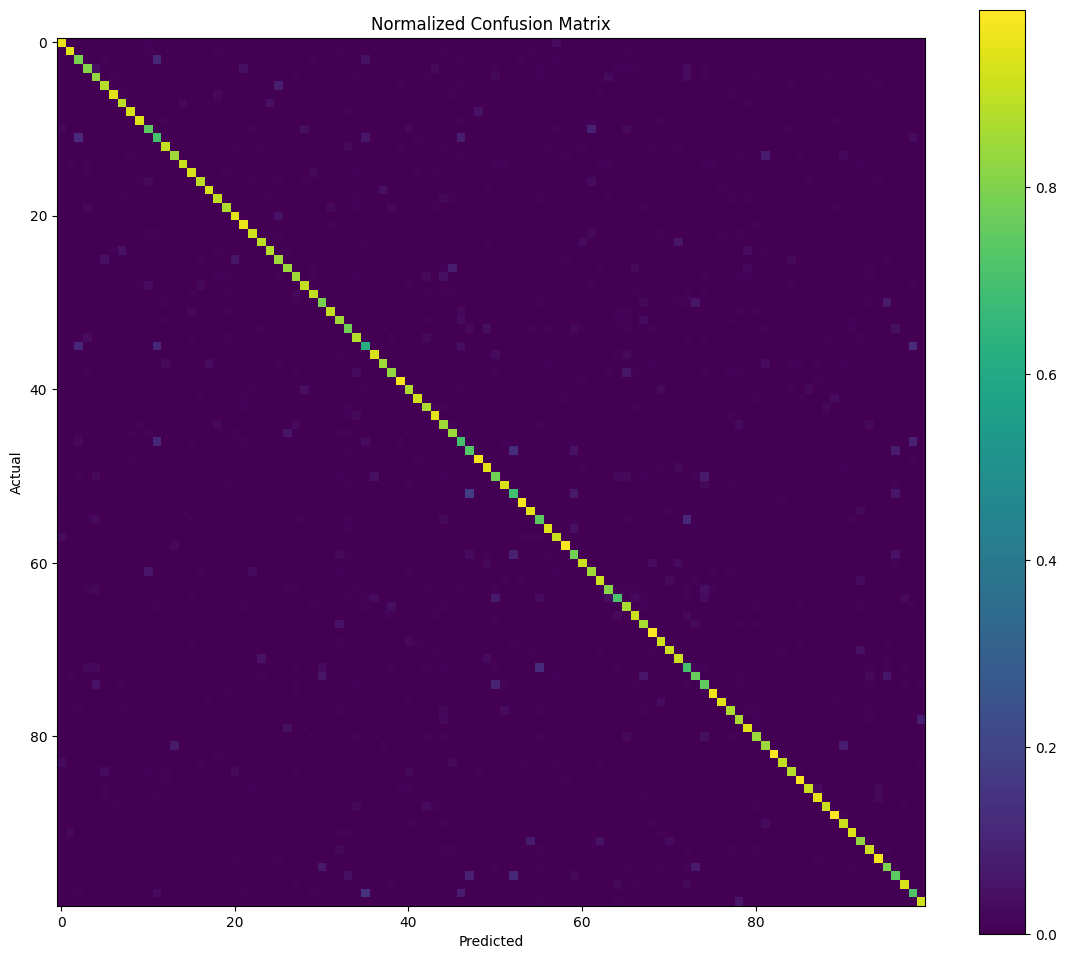

In [ ]:
# Normalized CM

cm_normalized = cm / cm.sum(axis=1,keepdims=True)


plt.figure(figsize=(14,12))


plt.imshow(cm_normalized)


plt.colorbar()


plt.title(
    "Normalized Confusion Matrix"
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)


plt.show()

In [ ]:
# Per Class Accuracy

class_accuracy = cm.diagonal()/cm.sum(axis=1)


for i,acc in enumerate(class_accuracy):

    print(

        test_dataset.classes[i],

        round(acc*100,2)

    )

apple 96.0
aquarium_fish 94.0
baby 79.0
bear 81.0
beaver 83.0
bed 88.0
bee 94.0
beetle 89.0
bicycle 93.0
bottle 94.0
bowl 74.0
boy 70.0
bridge 90.0
bus 85.0
butterfly 91.0
camel 93.0
can 89.0
castle 93.0
caterpillar 90.0
cattle 87.0
chair 94.0
chimpanzee 96.0
clock 92.0
cloud 89.0
cockroach 88.0
couch 85.0
crab 84.0
crocodile 85.0
cup 90.0
dinosaur 90.0
dolphin 79.0
elephant 90.0
flatfish 85.0
forest 78.0
fox 88.0
girl 62.0
hamster 93.0
house 85.0
kangaroo 83.0
keyboard 98.0
lamp 87.0
lawn_mower 92.0
leopard 87.0
lion 95.0
lizard 85.0
lobster 84.0
man 70.0
maple_tree 73.0
motorcycle 97.0
mountain 95.0
mouse 78.0
mushroom 93.0
oak_tree 69.0
orange 98.0
orchid 95.0
otter 74.0
palm_tree 94.0
pear 91.0
pickup_truck 98.0
pine_tree 78.0
plain 91.0
plate 85.0
poppy 92.0
porcupine 81.0
possum 71.0
rabbit 86.0
raccoon 91.0
ray 86.0
road 99.0
rocket 92.0
rose 91.0
sea 91.0
seal 70.0
shark 76.0
shrew 75.0
skunk 97.0
skyscraper 94.0
snail 87.0
snake 86.0
spider 94.0
squirrel 84.0
streetcar 84.0
su

In [ ]:
# CSV - Results

import pandas as pd


results=[]


results.append({

"Model":"ViT-Tiny-CutMix-RandAugment",

"Accuracy":accuracy,

"Precision":precision,

"Recall":recall,

"F1":f1

})


df=pd.DataFrame(results)


df.to_csv(

"/content/drive/MyDrive/final_results.csv",

index=False

)

In [ ]:
import pandas as pd


data={

"Experiment":[

"Baseline",
"Mixup",
"CutMix",
"RandAugment",
"Mixup+CutMix",
"Mixup+RandAug",
"CutMix+RandAug",
"Mixup+CutMix+RandAug"

],


"ViT-Tiny":[

86.96,
86.02,
86.91,
86.78,
87.0,
86.20,
87.41,
87.16

]

}

df=pd.DataFrame(data)


df

,Experiment,ViT-Tiny
0,Baseline,86.96
1,Mixup,86.02
2,CutMix,86.91
3,RandAugment,86.78
4,Mixup+CutMix,87.00
5,Mixup+RandAug,86.20
6,CutMix+RandAug,87.41
7,Mixup+CutMix+RandAug,87.16


In [ ]:
# Parameter Count

import timm


model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=100
)


parameters = sum(
    p.numel()
    for p in model.parameters()
)


print(
    "Parameters:",
    parameters/1e6,
    "Million"
)

Parameters: 5.543716 Million


In [ ]:
def load_model(model_path):

    model = timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=False,
        num_classes=100
    )


    checkpoint = torch.load(
        model_path,
        map_location=device
    )


    model.load_state_dict(
        checkpoint
    )


    model.to(device)

    model.eval()


    return model

In [ ]:
def get_predictions(model, loader):

    model.eval()


    all_labels=[]
    all_preds=[]


    with torch.no_grad():

        for images,labels in tqdm(loader):

            images = images.to(device)


            outputs=model(images)


            preds=torch.argmax(
                outputs,
                dim=1
            )


            all_preds.extend(
                preds.cpu().numpy()
            )


            all_labels.extend(
                labels.numpy()
            )


    return np.array(all_labels), np.array(all_preds)

In [ ]:
model_paths = {


"ViT-Tiny-Baseline":

"/content/drive/MyDrive/vit_tiny_baseline_best.pth",



"ViT-Tiny-Mixup":

"/content/drive/MyDrive/vit_tiny_mixup_best.pth",



"ViT-Tiny-CutMix":

"/content/drive/MyDrive/vit_tiny_cutmix_best.pth",



"ViT-Tiny-RandAugment":

"/content/drive/MyDrive/vit_tiny_randaugment_best (1).pth",



"ViT-Tiny-Mixup-CutMix":

"/content/drive/MyDrive/vit_tiny_mixup_cutmix_best.pth",



"ViT-Tiny-Mixup-RandAugment":

"/content/drive/MyDrive/vit_tiny_mixup_randaugment_best (3).pth",



"ViT-Tiny-CutMix-RandAugment":

"/content/drive/MyDrive/vit_tiny_cutmix_randaugment_best.pth",



"ViT-Tiny-Mixup-CutMix-RandAugment":

"/content/drive/MyDrive/vit_tiny_mixup_cutmix_randaugment_best.pth"

}

In [ ]:
import torch
import timm

import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
results=[]


for name,path in model_paths.items():


    print("\n======================")
    print(name)
    print("======================")


    model = load_model(path)


    y_true,y_pred = get_predictions(
        model,
        test_loader
    )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    precision = precision_score(
        y_true,
        y_pred,
        average="macro"
    )


    recall = recall_score(
        y_true,
        y_pred,
        average="macro"
    )


    f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )


    print(
        "Accuracy:",
        accuracy*100
    )


    print(
        "Precision:",
        precision
    )


    print(
        "Recall:",
        recall
    )


    print(
        "F1:",
        f1
    )


    results.append({

        "Model":name,

        "Accuracy (%)":accuracy*100,

        "Precision":precision,

        "Recall":recall,

        "F1-score":f1

    })


ViT-Tiny-Baseline


100%|██████████| 157/157 [00:21<00:00,  7.43it/s]


Accuracy: 86.96000000000001
Precision: 0.8708456888549305
Recall: 0.8696
F1: 0.8695698815929811

ViT-Tiny-Mixup


100%|██████████| 157/157 [00:18<00:00,  8.65it/s]


Accuracy: 86.02
Precision: 0.8616744690786973
Recall: 0.8602000000000001
F1: 0.860190775133793

ViT-Tiny-CutMix


...

Accuracy: 86.2
Precision: 0.862973981657238
Recall: 0.862
F1: 0.861750210461416

ViT-Tiny-CutMix-RandAugment


100%|██████████| 157/157 [00:17<00:00,  8.83it/s]


Accuracy: 87.41
Precision: 0.8750184744088004
Recall: 0.8741
F1: 0.8741411147175381

ViT-Tiny-Mixup-CutMix-RandAugment


100%|██████████| 157/157 [00:17<00:00,  8.90it/s]


Accuracy: 87.16000000000001
Precision: 0.8723658778141591
Recall: 0.8715999999999998
F1: 0.8713272729442124


In [ ]:
results_df = pd.DataFrame(results)


results_df

,Model,Accuracy (%),Precision,Recall,F1-score
0,ViT-Tiny-Baseline,86.96,0.870846,0.8696,0.869570
1,ViT-Tiny-Mixup,86.02,0.861674,0.8602,0.860191
2,ViT-Tiny-CutMix,86.91,0.870120,0.8691,0.868940
3,ViT-Tiny-RandAugment,86.78,0.868817,0.8678,0.867691
4,ViT-Tiny-Mixup-CutMix,87.07,0.871886,0.8707,0.870481
5,ViT-Tiny-Mixup-RandAugment,86.20,0.862974,0.8620,0.861750
6,ViT-Tiny-CutMix-RandAugment,87.41,0.875018,0.8741,0.874141
7,ViT-Tiny-Mixup-CutMix-RandAugment,87.16,0.872366,0.8716,0.871327


In [ ]:
baseline = results_df.iloc[0]["Accuracy (%)"]


results_df["Improvement (%)"] = (
    results_df["Accuracy (%)"] - baseline
)


results_df

,Model,Accuracy (%),Precision,Recall,F1-score,Improvement (%)
0,ViT-Tiny-Baseline,86.96,0.870846,0.8696,0.869570,0.00
1,ViT-Tiny-Mixup,86.02,0.861674,0.8602,0.860191,-0.94
2,ViT-Tiny-CutMix,86.91,0.870120,0.8691,0.868940,-0.05
3,ViT-Tiny-RandAugment,86.78,0.868817,0.8678,0.867691,-0.18
4,ViT-Tiny-Mixup-CutMix,87.07,0.871886,0.8707,0.870481,0.11
5,ViT-Tiny-Mixup-RandAugment,86.20,0.862974,0.8620,0.861750,-0.76
6,ViT-Tiny-CutMix-RandAugment,87.41,0.875018,0.8741,0.874141,0.45
7,ViT-Tiny-Mixup-CutMix-RandAugment,87.16,0.872366,0.8716,0.871327,0.20


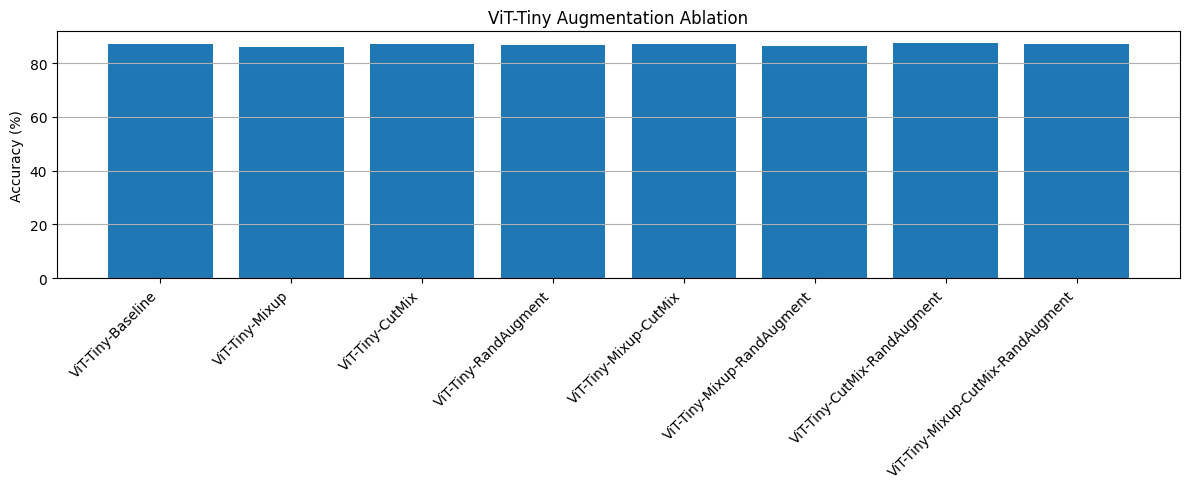

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))


plt.bar(
    results_df["Model"],
    results_df["Accuracy (%)"]
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.ylabel(
    "Accuracy (%)"
)


plt.title(
    "ViT-Tiny Augmentation Ablation"
)


plt.grid(
    axis="y"
)


plt.tight_layout()


plt.savefig(
"/content/drive/MyDrive/vit_tiny_accuracy_ablation.png",
dpi=600
)


plt.show()

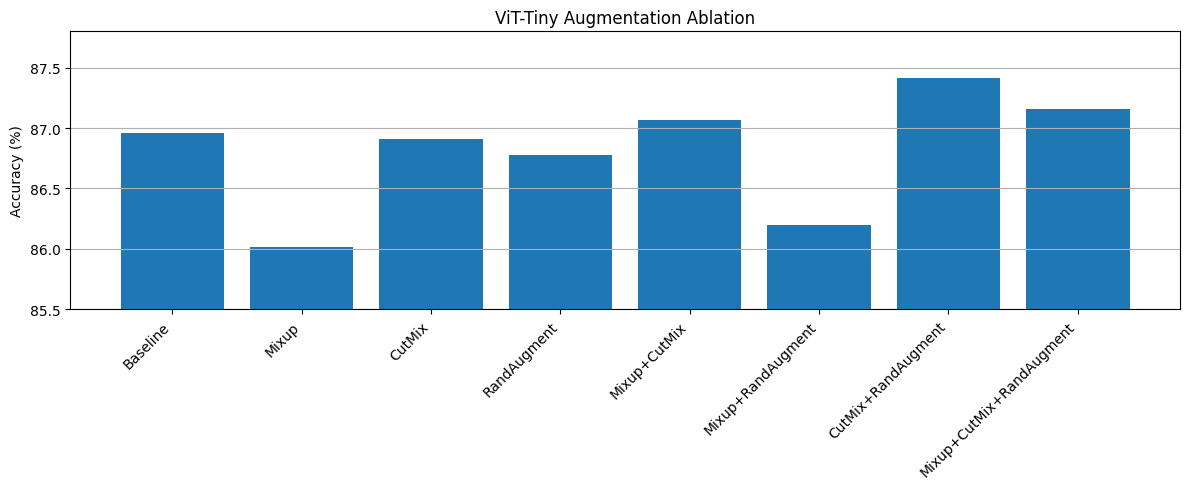

In [ ]:
import matplotlib.pyplot as plt

# Hard-coded results
models = [
    "Baseline",
    "Mixup",
    "CutMix",
    "RandAugment",
    "Mixup+CutMix",
    "Mixup+RandAugment",
    "CutMix+RandAugment",
    "Mixup+CutMix+RandAugment"
]

accuracy = [
    86.96,
    86.02,
    86.91,
    86.78,
    87.07,
    86.20,
    87.41,
    87.16
]

plt.figure(figsize=(12,5))

plt.bar(
    models,
    accuracy
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel("Accuracy (%)")

plt.title("ViT-Tiny Augmentation Ablation")

# Zoom y-axis
plt.ylim(85.5, 87.8)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/vit_tiny_accuracy_ablation.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

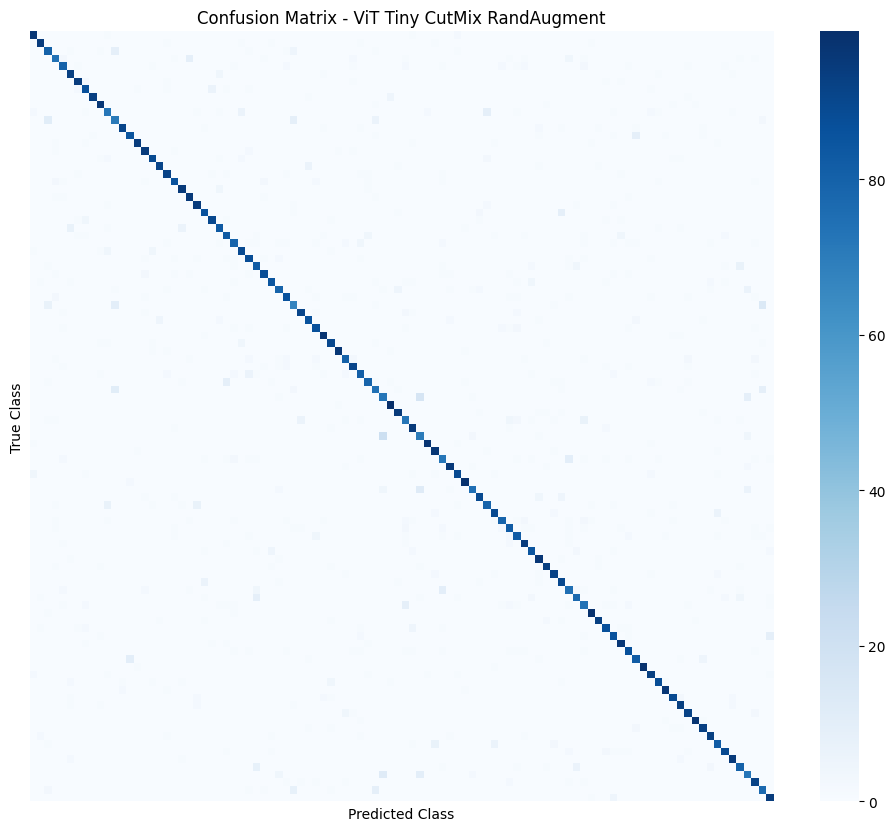

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(figsize=(12,10))


sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False
)


plt.xlabel(
"Predicted Class"
)


plt.ylabel(
"True Class"
)


plt.title(
"Confusion Matrix - ViT Tiny CutMix RandAugment"
)


plt.savefig(
"confusion_matrix.png",
dpi=600,
bbox_inches="tight"
)


plt.show()

In [ ]:
class_acc = (
cm.diagonal() /
cm.sum(axis=1)
)


class_df = pd.DataFrame({

"Class":test_dataset.classes,

"Accuracy":class_acc*100

})


class_df.sort_values(
"Accuracy"
)

,Class,Accuracy
35,girl,67.0
52,oak_tree,70.0
11,boy,71.0
10,bowl,72.0
47,maple_tree,72.0
...,...,...
39,keyboard,97.0
82,sunflower,98.0
58,pickup_truck,98.0
75,skunk,98.0


In [ ]:
class_df.nlargest(
10,
"Accuracy"
)

,Class,Accuracy
48,motorcycle,99.0
58,pickup_truck,98.0
75,skunk,98.0
82,sunflower,98.0
39,keyboard,97.0
53,orange,97.0
89,tractor,97.0
0,apple,96.0
9,bottle,96.0
41,lawn_mower,96.0


In [ ]:
class_df.nsmallest(
10,
"Accuracy"
)

,Class,Accuracy
35,girl,67.0
52,oak_tree,70.0
11,boy,71.0
10,bowl,72.0
47,maple_tree,72.0
50,mouse,72.0
55,otter,72.0
96,willow_tree,72.0
3,bear,74.0
46,man,74.0


In [ ]:
wrong_indices = np.where(
    y_true != y_pred
)[0]


print(
len(wrong_indices)
)

1284


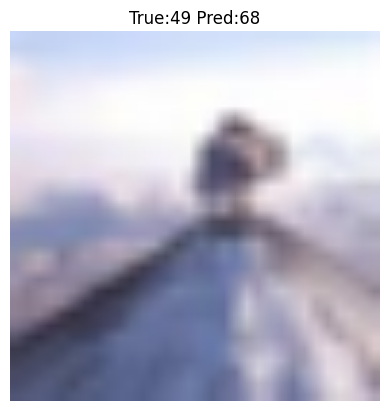

In [ ]:
idx = wrong_indices[0]


img,label=test_dataset[idx]


plt.imshow(
img.permute(1,2,0)
)


plt.title(
f"True:{y_true[idx]} Pred:{y_pred[idx]}"
)


plt.axis("off")

plt.show()

In [ ]:
!pip install ptflops

In [ ]:
from ptflops import get_model_complexity_info


macs,params=get_model_complexity_info(
model,
(3,224,224),
as_strings=True
)


print(macs)
print(params)

VisionTransformer(
  5.5 M, 99.141% Params, 910.9 MMac, 99.801% MACs, 
  (patch_embed): PatchEmbed(
    147.65 k, 2.663% Params, 28.94 MMac, 3.171% MACs, 
    (proj): Conv2d(147.65 k, 2.663% Params, 28.94 MMac, 3.171% MACs, 3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
  )
  (pos_drop): Dropout(0, 0.000% Params, 0.0 Mac, 0.000% MACs, p=0.0, inplace=False)
  (patch_drop): Identity(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
  (norm_pre): Identity(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
  (blocks): Sequential(
    5.33 M, 96.130% Params, 881.94 MMac, 96.628% MACs, 
    (0): Block(
      444.1 k, 8.011% Params, 73.49 MMac, 8.052% MACs, 
      (norm1): LayerNorm(0, 0.000% Params, 0.0 Mac, 0.000% MACs, (192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        148.22 k, 2.674% Params, 15.06 MMac, 1.650% MACs, 
        (qkv): Linear(111.17 k, 2.005% Params, 21.9 MMac, 2.399% MACs, in_features=192, out_features=

In [ ]:
checkpoint = torch.load(
"/content/drive/MyDrive/vit_tiny_cutmix_randaugment_checkpoint.pth",
map_location="cpu"
)


print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_acc'])


In [ ]:
import matplotlib.pyplot as plt


train_history = [
3.4893,
2.8967,
2.7180,
2.6689,
2.5792,
2.5267,
2.4601,
2.4323,
2.3989,
2.3844,
2.2964,
2.2939,
2.2595,
2.2607,
2.2053,
2.1842,
2.1613,
2.1749,
2.1735,
2.1697
]


val_loss_history = [
1.2622,
1.0658,
0.9086,
0.8699,
0.8391,
0.7934,
0.7800,
0.7425,
0.7266,
0.7285,
0.7127,
0.6774,
0.6762,
0.6514,
0.6506,
0.6495,
0.6344,
0.6393,
0.6272,
0.6294
]


val_acc_history = [
70.42,
75.91,
79.19,
80.67,
82.06,
82.50,
82.73,
84.32,
84.05,
84.65,
84.89,
85.58,
85.79,
86.34,
86.39,
86.79,
86.70,
87.07,
87.08,
87.16
]


epochs = range(1,21)

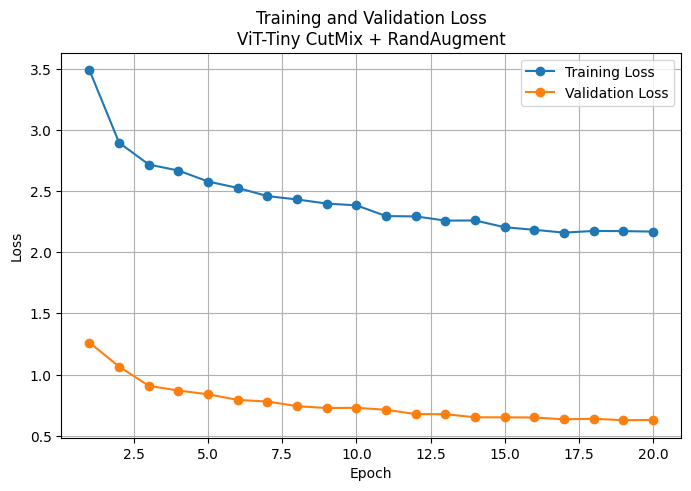

In [ ]:
plt.figure(figsize=(8,5))


plt.plot(
    epochs,
    train_history,
    marker="o",
    label="Training Loss"
)


plt.plot(
    epochs,
    val_loss_history,
    marker="o",
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "Training and Validation Loss\nViT-Tiny CutMix + RandAugment"
)


plt.legend()

plt.grid()


plt.savefig(
"/content/drive/MyDrive/vit_tiny_cutmix_randaugment_loss_curve.png",
dpi=600,
bbox_inches="tight"
)


plt.show()

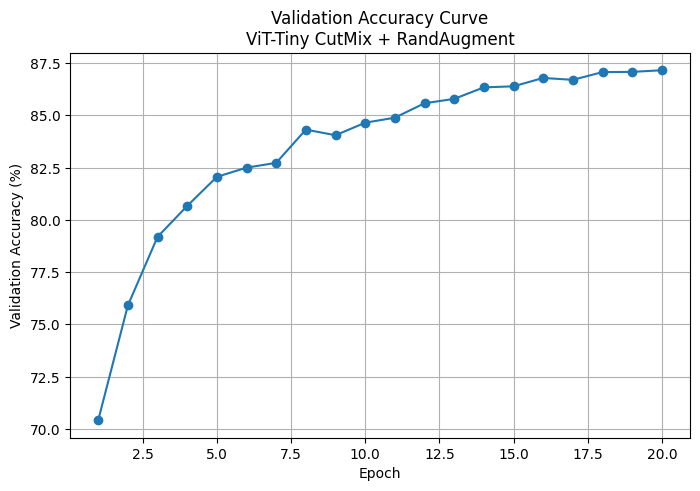

In [ ]:
plt.figure(figsize=(8,5))


plt.plot(
    epochs,
    val_acc_history,
    marker="o"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Validation Accuracy (%)"
)


plt.title(
    "Validation Accuracy Curve\nViT-Tiny CutMix + RandAugment"
)


plt.grid()


plt.savefig(
"/content/drive/MyDrive/vit_tiny_cutmix_randaugment_accuracy_curve.png",
dpi=600,
bbox_inches="tight"
)


plt.show()

# **AV**

In [ ]:
model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=100
)


best_model_path = "/content/drive/MyDrive/vit_tiny_cutmix_randaugment_best.pth"


checkpoint = torch.load(
    best_model_path,
    map_location=device
)


model.load_state_dict(checkpoint)


model=model.to(device)

model.eval()


print("Best ViT-Tiny loaded")

Best ViT-Tiny loaded


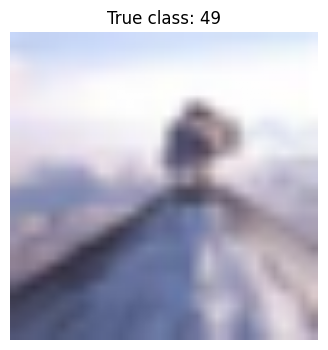

In [ ]:
image,label = test_dataset[0]


plt.figure(figsize=(4,4))

plt.imshow(
    image.permute(1,2,0)
)


plt.title(
    f"True class: {label}"
)


plt.axis("off")

plt.show()

In [ ]:
input_image = image.unsqueeze(0).to(device)

In [ ]:
with torch.no_grad():

    output = model(
        input_image
    )


prediction = torch.argmax(
    output,
    dim=1
)


print(
    "True label:",
    label
)


print(
    "Predicted label:",
    prediction.item()
)

True label: 49
Predicted label: 49


In [ ]:
attention_maps=[]


def attention_hook(module, input, output):

    x = input[0]


    B,N,C = x.shape


    qkv = module.qkv(x)


    qkv = qkv.reshape(
        B,
        N,
        3,
        module.num_heads,
        C // module.num_heads
    )


    qkv = qkv.permute(
        2,
        0,
        3,
        1,
        4
    )


    q,k,v = qkv[0],qkv[1],qkv[2]


    attn = (
        q @ k.transpose(-2,-1)
    ) * module.scale


    attn = attn.softmax(
        dim=-1
    )


    attention_maps.append(
        attn.detach()
    )

In [ ]:
for block in model.blocks:

    block.attn.register_forward_hook(
        attention_hook
    )

In [ ]:
attention_maps.clear()

In [ ]:
with torch.no_grad():

    output=model(
        input_image
    )


print(
"Number of layers:",
len(attention_maps)
)


print(
"Attention shape:",
attention_maps[0].shape
)

Number of layers: 12
Attention shape: torch.Size([1, 3, 197, 197])


In [ ]:
def attention_rollout(attention_maps):


    result=torch.eye(
        attention_maps[0].size(-1)
    ).to(device)



    for attention in attention_maps:


        attention = attention[0]


        attention = attention.mean(
            dim=0
        )


        identity=torch.eye(
            attention.size(0)
        ).to(device)


        attention = attention + identity


        attention = attention / attention.sum(
            dim=-1,
            keepdim=True
        )


        result = attention @ result



    mask=result[0,1:]


    return mask

In [ ]:
attention_mask = attention_rollout(
    attention_maps
)


print(
attention_mask.shape
)

torch.Size([196])


In [ ]:
import cv2

mask = attention_mask.reshape(
    14,
    14
)


mask = mask.cpu().numpy()


mask=cv2.resize(
    mask,
    (224,224)
)


mask=(mask-mask.min())/(mask.max()-mask.min())

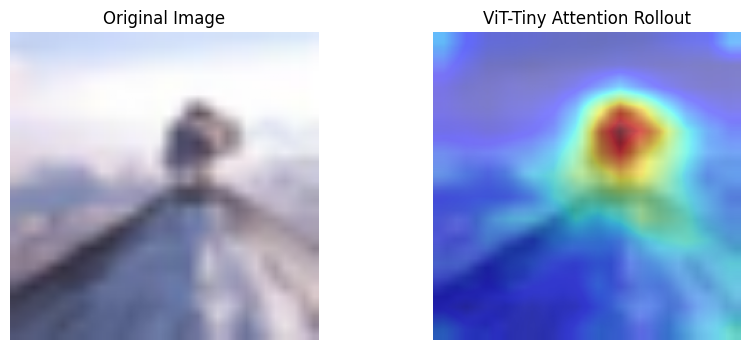

In [ ]:
plt.figure(figsize=(10,4))


plt.subplot(1,2,1)

plt.imshow(
    image.permute(1,2,0)
)

plt.title("Original Image")

plt.axis("off")



plt.subplot(1,2,2)


plt.imshow(
    image.permute(1,2,0)
)


plt.imshow(
    mask,
    cmap="jet",
    alpha=0.5
)


plt.title(
"ViT-Tiny Attention Rollout"
)


plt.axis("off")


plt.show()

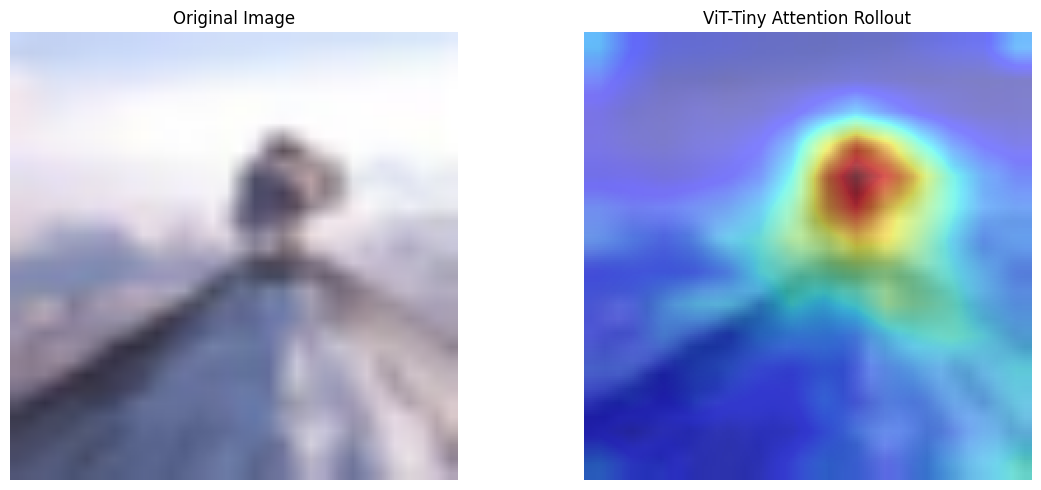

In [ ]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

plt.imshow(
    image.permute(1,2,0).cpu()
)

plt.title("Original Image")

plt.axis("off")



plt.subplot(1,2,2)

plt.imshow(
    image.permute(1,2,0).cpu()
)


plt.imshow(
    mask,
    cmap="jet",
    alpha=0.5
)


plt.title(
    "ViT-Tiny Attention Rollout"
)

plt.axis("off")



plt.tight_layout()


plt.savefig(
    "/content/drive/MyDrive/vit_tiny_attention_rollout.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# **RA**

In [ ]:
import torch
import timm
import torch.nn as nn


device="cuda" if torch.cuda.is_available() else "cpu"


model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=100
)


best_model_path="/content/drive/MyDrive/vit_tiny_cutmix_randaugment_best.pth"


checkpoint=torch.load(
    best_model_path,
    map_location=device
)


model.load_state_dict(checkpoint)


model=model.to(device)

model.eval()


print("Best model loaded")

Best model loaded


In [ ]:
from torchvision import transforms


blur_transform = transforms.Compose([

    transforms.GaussianBlur(
        kernel_size=5
    )

])


brightness_transform = transforms.Compose([

    transforms.ColorJitter(
        brightness=0.5
    )

])


contrast_transform = transforms.Compose([

    transforms.ColorJitter(
        contrast=0.5
    )

])

In [ ]:
import torch


def add_noise(image):

    noise=torch.randn_like(image)*0.1

    noisy=image+noise


    noisy=torch.clamp(
        noisy,
        0,
        1
    )


    return noisy

In [ ]:
from tqdm import tqdm
import torch


def evaluate_robustness(
    model,
    dataset,
    transform=None,
    noise=False
):

    model.eval()

    correct=0
    total=0


    with torch.no_grad():

        for img,label in tqdm(dataset):


            # img is already Tensor

            if transform:
                img = transform(img)


            if noise:
                img = add_noise(img)


            img = img.unsqueeze(0).to(device)


            label=torch.tensor(
                label
            ).to(device)



            output=model(img)


            pred=torch.argmax(
                output,
                dim=1
            )


            correct += (
                pred==label
            ).sum().item()


            total += 1



    return 100*correct/total

In [ ]:
results={}

In [ ]:
clean_acc=evaluate_robustness(
    model,
    test_dataset
)

print(clean_acc)

100%|██████████| 10000/10000 [01:46<00:00, 93.55it/s] 

87.41


In [ ]:
noise_acc=evaluate_robustness(
    model,
    test_dataset,
    noise=True
)


print(noise_acc)

100%|██████████| 10000/10000 [01:24<00:00, 117.96it/s]

58.8


In [ ]:
blur_acc=evaluate_robustness(
    model,
    test_dataset,
    transform=blur_transform
)


print(blur_acc)

100%|██████████| 10000/10000 [01:37<00:00, 102.46it/s]

87.2


In [ ]:
brightness_acc=evaluate_robustness(
    model,
    test_dataset,
    transform=brightness_transform
)


print(brightness_acc)

100%|██████████| 10000/10000 [01:21<00:00, 122.58it/s]

86.59


In [ ]:
contrast_acc=evaluate_robustness(
    model,
    test_dataset,
    transform=contrast_transform
)


print(contrast_acc)

100%|██████████| 10000/10000 [01:18<00:00, 126.64it/s]

86.83


In [ ]:
import pandas as pd


robustness_df=pd.DataFrame({

"Condition":[
"Clean",
"Gaussian Noise",
"Blur",
"Brightness",
"Contrast"
],

"Accuracy":[

clean_acc,
noise_acc,
blur_acc,
brightness_acc,
contrast_acc

]

})


robustness_df

,Condition,Accuracy
0,Clean,87.41
1,Gaussian Noise,58.80
2,Blur,87.20
3,Brightness,86.59
4,Contrast,86.83


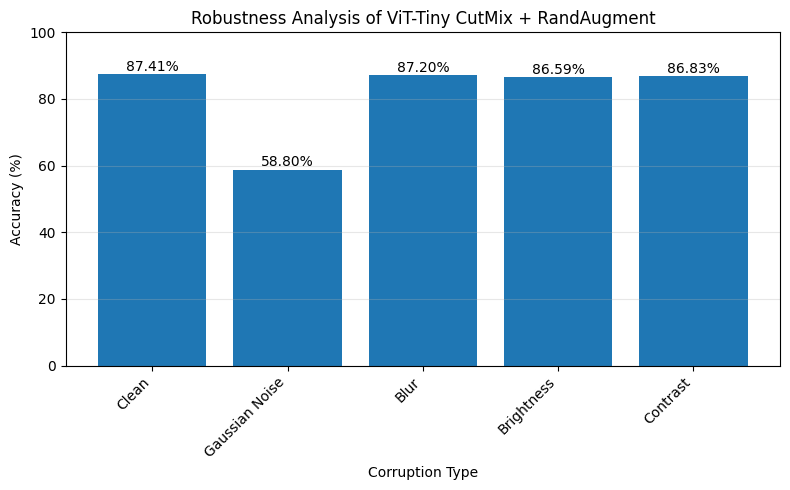

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


bars = plt.bar(
    robustness_df["Condition"],
    robustness_df["Accuracy"]
)


plt.xlabel(
    "Corruption Type"
)


plt.ylabel(
    "Accuracy (%)"
)


plt.title(
    "Robustness Analysis of ViT-Tiny CutMix + RandAugment"
)


plt.ylim(
    0,
    100
)


plt.xticks(
    rotation=45,
    ha="right"
)


# Add values on top of bars

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    "/content/drive/MyDrive/vit_tiny_robustness_analysis.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()

In [ ]:
clean_acc = robustness_df.loc[
    robustness_df["Condition"]=="Clean",
    "Accuracy"
].values[0]


robustness_df["Accuracy Drop (%)"] = (
    clean_acc - robustness_df["Accuracy"]
)


robustness_df

,Condition,Accuracy,Accuracy Drop (%)
0,Clean,87.41,0.00
1,Gaussian Noise,58.80,28.61
2,Blur,87.20,0.21
3,Brightness,86.59,0.82
4,Contrast,86.83,0.58
